In [4]:
import nltk
nltk.download("stopwords", quiet=True)

from urllib.request import urlopen
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from nltk.corpus import stopwords
import string
from sklearn.metrics import classification_report, accuracy_score, f1_score

import time

это с семинаров по нлп:

In [1]:
!pip install torch==2.2.2 torchtext==0.17.2 torchaudio==2.2.2 torchvision==0.17.2 torchdata==0.7.1
!pip install portalocker==2.8.2
!pip install numpy==1.26.4

In [23]:
import numpy as np

import torch
import torch.nn as nn

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter

In [6]:
response = urlopen('https://api.openf1.org/v1/race_control')
data = json.loads(response.read().decode('utf-8'))
df = pd.DataFrame(data)
df

,meeting_key,session_key,date,driver_number,lap_number,category,flag,scope,sector,qualifying_phase,message
0,1140,7763,2023-02-24T06:45:11+00:00,NaN,NaN,Other,None,None,NaN,NaN,RISK OF RAIN FOR THIS SESSION IS 0%
1,1140,7763,2023-02-24T06:57:05+00:00,NaN,NaN,Drs,None,None,NaN,NaN,DRS ENABLED
2,1140,7763,2023-02-24T07:00:00+00:00,NaN,NaN,Flag,GREEN,Track,NaN,NaN,GREEN LIGHT - PIT EXIT OPEN
3,1140,7763,2023-02-24T07:00:00.217000+00:00,NaN,NaN,SessionStatus,None,None,NaN,NaN,SESSION STARTED
4,1140,7763,2023-02-24T11:00:03+00:00,NaN,NaN,Flag,DOUBLE YELLOW,Sector,6.0,NaN,DOUBLE YELLOW IN TRACK SECTOR 6
...,...,...,...,...,...,...,...,...,...,...,...
20708,1305,11470,2026-02-18T15:58:02+00:00,NaN,NaN,Other,None,None,NaN,NaN,STANDING START
20709,1305,11470,2026-02-18T16:00:44+00:00,NaN,NaN,Flag,DOUBLE YELLOW,Sector,2.0,NaN,DOUBLE YELLOW IN TRACK SECTOR 2
20710,1305,11470,2026-02-18T16:01:13+00:00,NaN,NaN,Flag,CLEAR,Sector,2.0,NaN,CLEAR IN TRACK SECTOR 2
20711,1305,11470,2026-02-18T16:01:25+00:00,NaN,NaN,Other,None,None,NaN,NaN,RED FLAG - RACE SUSPENDED


In [12]:
len(df)

20713

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20713 entries, 0 to 20712
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   meeting_key       20713 non-null  int64  
 1   session_key       20713 non-null  int64  
 2   date              20713 non-null  object 
 3   driver_number     2461 non-null   float64
 4   lap_number        8615 non-null   float64
 5   category          20713 non-null  object 
 6   flag              9826 non-null   object 
 7   scope             9826 non-null   object 
 8   sector            5552 non-null   float64
 9   qualifying_phase  2857 non-null   float64
 10  message           20713 non-null  object 
dtypes: float64(4), int64(2), object(5)
memory usage: 1.7+ MB


In [14]:
df.columns

Index(['meeting_key', 'session_key', 'date', 'driver_number', 'lap_number',
       'category', 'flag', 'scope', 'sector', 'qualifying_phase', 'message'],
      dtype='object')

#meeting_key и session_key

meeting_key - идентификатор встречи-обсуждения

session_key - идентификатор сессии (гонки)

In [15]:
df['meeting_key'].nunique(), df['session_key'].nunique()

(82, 400)

распределение количества событий по сессиям

In [16]:
session_counts = df['session_key'].value_counts()
session_counts.describe()

,count
count,400.00000
mean,51.78250
std,41.36548
min,5.00000
25%,22.75000
50%,43.00000
75%,67.25000
max,287.00000


In [17]:
session_counts

,count
session_key,
11291,287
11299,269
9094,244
9900,217
9118,212
...,...
9999,6
9870,6
9657,5


посмотрим пересечение

In [18]:
df.groupby('meeting_key')['session_key'].nunique()

,session_key
meeting_key,
1140,3
1141,5
1142,5
1143,5
1207,5
...,...
1285,5
1286,5
1287,5


In [19]:
df.groupby('session_key')['meeting_key'].nunique()

,meeting_key
session_key,
7763,1
7764,1
7765,1
7766,1
7767,1
...,...
11466,1
11467,1
11468,1


более значимым для нас будет 1 сессия/гонка, на встречах могут обсуждать несколько гонок, нм нужны результаты только 1. в дальнейшем удалим признак meeting_key

#date

дата время инцидента/события

In [20]:
df['date']

,date
0,2023-02-24T06:45:11+00:00
1,2023-02-24T06:57:05+00:00
2,2023-02-24T07:00:00+00:00
3,2023-02-24T07:00:00.217000+00:00
4,2023-02-24T11:00:03+00:00
...,...
20708,2026-02-18T15:58:02+00:00
20709,2026-02-18T16:00:44+00:00
20710,2026-02-18T16:01:13+00:00
20711,2026-02-18T16:01:25+00:00


In [21]:
df['date'] = pd.to_datetime(df['date'], format='ISO8601')

In [22]:
df['date'].max(), df['date'].min(), df['date'].max() - df['date'].min()

(Timestamp('2026-06-14 14:36:32+0000', tz='UTC'),
 Timestamp('2023-02-23 07:00:00+0000', tz='UTC'),
 Timedelta('1207 days 07:36:32'))

данные за 3 года, разобьем

In [23]:
df['hour'] = df['date'].dt.hour
df['minute'] = df['date'].dt.minute
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

<Axes: >

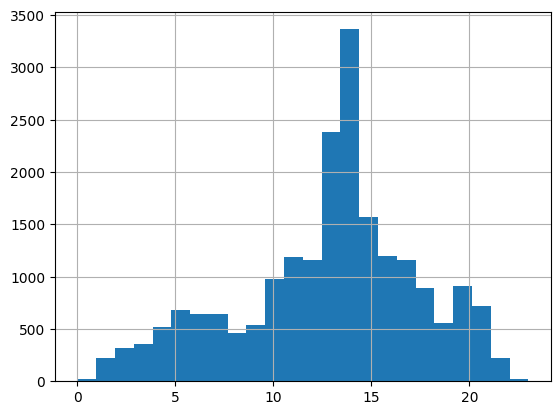

In [24]:
df['hour'].hist(bins=24)

больше всего событий за дневное время

<Axes: >

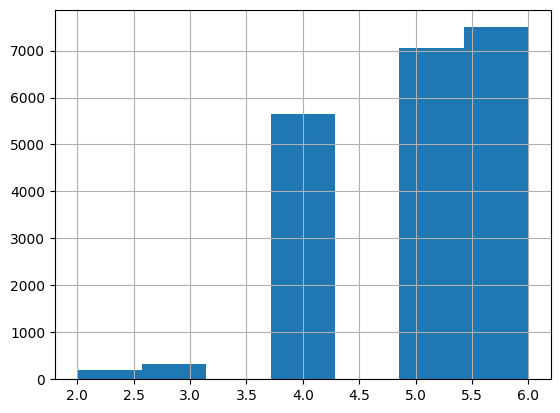

In [25]:
df['day_of_week'].hist(bins=7)

чаще всего в выходные/четверг

меньше всего гонок зимой

<Axes: >

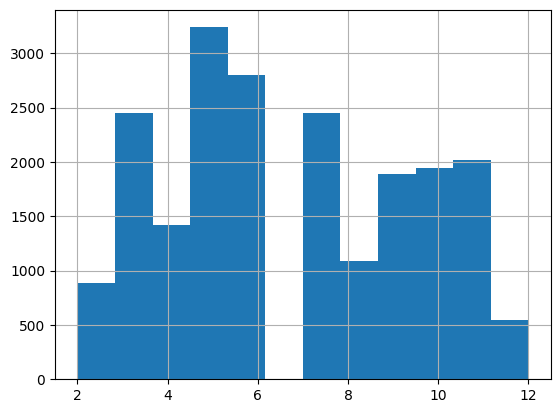

In [26]:
df['month'].hist(bins=12)

#driver_number

если событие связано с водителем, то указывается его номер

In [27]:
df[df['driver_number'].notna()].shape[0]

2461

заметим, что номер гонщика и так указывается в сообщении

In [28]:
df[df['driver_number'].notnull()]

,meeting_key,session_key,date,driver_number,lap_number,category,flag,scope,sector,qualifying_phase,message,hour,minute,day_of_week,month
60,1140,7764,2023-02-25 08:43:53+00:00,11.0,NaN,Flag,BLUE,Driver,NaN,NaN,WAVED BLUE FLAG FOR CAR 11 (PER) TIMED AT 11:4...,8,43,5,2
63,1140,7764,2023-02-25 08:51:23+00:00,77.0,NaN,Flag,BLUE,Driver,NaN,NaN,WAVED BLUE FLAG FOR CAR 77 (BOT) TIMED AT 11:5...,8,51,5,2
150,1140,9222,2023-02-23 11:32:52+00:00,43.0,NaN,Flag,BLUE,Driver,NaN,NaN,WAVED BLUE FLAG FOR CAR 43 TIMED AT 14:32:51,11,32,3,2
180,1140,9222,2023-02-23 11:48:20+00:00,42.0,NaN,Flag,BLUE,Driver,NaN,NaN,WAVED BLUE FLAG FOR CAR 42 TIMED AT 14:48:20,11,48,3,2
200,1141,7765,2023-03-03 11:59:07+00:00,14.0,NaN,CarEvent,None,None,NaN,NaN,CAR 14 (ALO) OFF TRACK AND CONTINUED AT TURN 4,11,59,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20502,1304,11467,2026-02-13 16:48:17+00:00,43.0,NaN,Flag,BLUE,Driver,NaN,NaN,WAVED BLUE FLAG FOR CAR 43 (COL) TIMED AT 19:4...,16,48,4,2
20554,1304,11467,2026-02-13 17:04:06+00:00,41.0,NaN,Flag,BLUE,Driver,NaN,NaN,WAVED BLUE FLAG FOR CAR 41 (LIN) TIMED AT 20:0...,17,4,4,2
20555,1304,11467,2026-02-13 17:05:10+00:00,41.0,NaN,Flag,BLUE,Driver,NaN,NaN,WAVED BLUE FLAG FOR CAR 41 (LIN) TIMED AT 20:0...,17,5,4,2
20660,1305,11470,2026-02-18 10:15:35+00:00,41.0,NaN,Flag,BLUE,Driver,NaN,NaN,WAVED BLUE FLAG FOR CAR 41 (LIN) TIMED AT 13:1...,10,15,2,2


больше всего событий с 77 номером - Валттери Боттас, а 42 номер ни за кем не закреплен и используется тестовыми пилотами, с ним только 1 событие

In [29]:
drivers = df['driver_number'].value_counts()
drivers

,count
driver_number,
77.0,207
18.0,171
2.0,161
31.0,156
24.0,145
23.0,138
11.0,130
27.0,125
10.0,123


<Axes: xlabel='driver_number'>

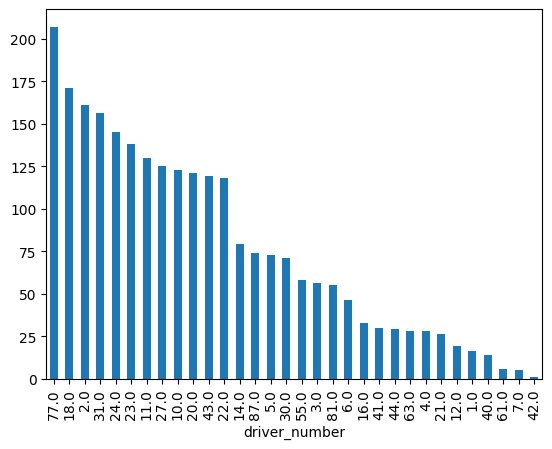

In [30]:
drivers.plot(kind='bar')

#lap_number

номер круга, когда произошел инцидент

In [31]:
df['lap_number'].notna().sum()

np.int64(8615)

количество кругов часто разное, зависит от трассы

In [32]:
df['lap_number'].max() - df['lap_number'].min()

78.0

больше всего записей за 1 круг

In [33]:
laps = df['lap_number'].value_counts()
laps

,count
lap_number,
1.0,1659
19.0,220
57.0,189
58.0,169
2.0,154
...,...
73.0,10
75.0,9
74.0,8


<Axes: >

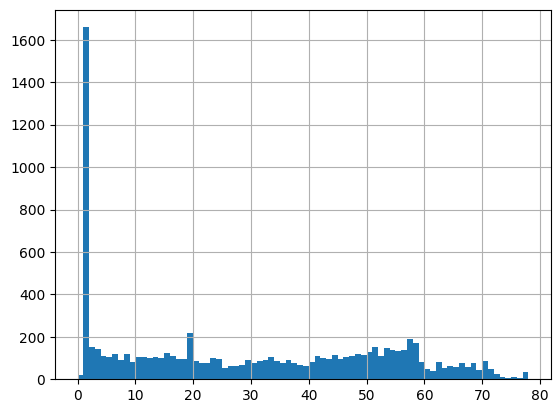

In [34]:
df['lap_number'].hist(bins=78)

#category

In [35]:
df['category'].notna().sum()

np.int64(20713)

In [36]:
cats = df['category'].value_counts()
cats

,count
category,
Flag,9826
Other,8297
SessionStatus,1592
Drs,429
SafetyCar,330
CarEvent,239


<Axes: ylabel='count'>

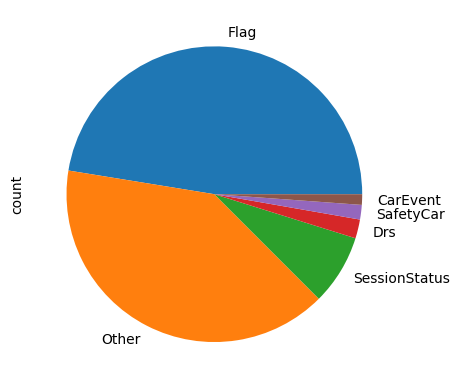

In [37]:
cats.plot(kind='pie')

drs - Подвижный элемент заднего антикрыла гоночного болида. При нажатии кнопки пилотом створка крыла приподнимается, пропуская воздух. Это «сбрасывает» прижимную силу и позволяет автомобилю резко ускориться на прямых участках для облегчения обгона

In [38]:
drs = df[df['category']=='Drs']
drs

,meeting_key,session_key,date,driver_number,lap_number,category,flag,scope,sector,qualifying_phase,message,hour,minute,day_of_week,month
1,1140,7763,2023-02-24 06:57:05+00:00,NaN,NaN,Drs,None,None,NaN,NaN,DRS ENABLED,6,57,4,2
21,1140,7763,2023-02-24 12:14:08+00:00,NaN,NaN,Drs,None,None,NaN,NaN,DRS ENABLED,12,14,4,2
30,1140,7763,2023-02-24 15:16:11+00:00,NaN,NaN,Drs,None,None,NaN,NaN,DRS ENABLED,15,16,4,2
49,1140,7764,2023-02-25 06:57:50+00:00,NaN,NaN,Drs,None,None,NaN,NaN,DRS ENABLED,6,57,5,2
58,1140,7764,2023-02-25 07:18:58+00:00,NaN,NaN,Drs,None,None,NaN,NaN,DRS ENABLED,7,18,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17127,1277,9943,2025-07-05 14:17:40+00:00,NaN,NaN,Drs,None,None,NaN,NaN,DRS ENABLED,14,17,5,7
17231,1277,9947,2025-07-06 13:57:07+00:00,NaN,1.0,Drs,None,None,NaN,NaN,DRS DISABLED,13,57,6,7
17262,1277,9947,2025-07-06 14:18:12+00:00,NaN,8.0,Drs,None,None,NaN,NaN,DRS ENABLED,14,18,6,7
17264,1277,9947,2025-07-06 14:23:23+00:00,NaN,11.0,Drs,None,None,NaN,NaN,DRS DISABLED,14,23,6,7


In [39]:
drs['message'].unique()

array(['DRS ENABLED', 'DRS DISABLED'], dtype=object)

In [40]:
ss = df[df['category']=='SessionStatus']
ss['message'].unique()

array(['SESSION STARTED', 'SESSION ABORTED', 'SESSION FINISHED'],
      dtype=object)

In [41]:
sc = df[df['category']=='SafetyCar']
sc['message'].unique()

array(['VIRTUAL SAFETY CAR DEPLOYED', 'SAFETY CAR DEPLOYED',
       'VIRTUAL SAFETY CAR ENDING', 'SAFETY CAR IN THIS LAP',
       'SAFETY CAR THROUGH THE PIT LANE', 'VSC DEPLOYED', 'VSC ENDING'],
      dtype=object)

In [42]:
df[df['category']=='CarEvent']


,meeting_key,session_key,date,driver_number,lap_number,category,flag,scope,sector,qualifying_phase,message,hour,minute,day_of_week,month
200,1141,7765,2023-03-03 11:59:07+00:00,14.0,NaN,CarEvent,None,None,NaN,NaN,CAR 14 (ALO) OFF TRACK AND CONTINUED AT TURN 4,11,59,4,3
205,1141,7765,2023-03-03 12:07:11+00:00,4.0,NaN,CarEvent,None,None,NaN,NaN,CAR 4 (NOR) OFF TRACK AND CONTINUED AT TURN 1,12,7,4,3
206,1141,7765,2023-03-03 12:09:21+00:00,55.0,NaN,CarEvent,None,None,NaN,NaN,CAR 55 (SAI) SPUN AND CONTINUED AT TURN 9,12,9,4,3
222,1141,7766,2023-03-03 15:11:30+00:00,81.0,NaN,CarEvent,None,None,NaN,NaN,CAR 81 (PIA) OFF TRACK AND CONTINUED AT TURN 1,15,11,4,3
225,1141,7766,2023-03-03 15:39:59+00:00,2.0,NaN,CarEvent,None,None,NaN,NaN,CAR 2 (SAR) OFF TRACK AND CONTINUED AT TURN 10,15,39,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5961,1232,9491,2024-04-06 02:47:04+00:00,3.0,NaN,CarEvent,None,None,NaN,NaN,CAR 3 (RIC) SPUN AND CONTINUED AT TURN 2,2,47,5,4
6070,1233,9663,2024-04-19 04:22:02+00:00,44.0,NaN,CarEvent,None,None,NaN,NaN,CAR 44 (HAM) OFF TRACK AND CONTINUED AT TURN 6,4,22,4,4
6089,1233,9664,2024-04-20 07:17:35+00:00,2.0,NaN,CarEvent,None,None,NaN,1.0,CAR 2 (SAR) SPUN AND CONTINUED AT TURN 9,7,17,5,4
6169,1233,9668,2024-04-19 08:13:23+00:00,16.0,NaN,CarEvent,None,None,NaN,3.0,CAR 16 (LEC) SPUN AND CONTINUED AT TURN 9,8,13,4,4


In [43]:
f = df[df['category']=='Flag']
f['message'].unique()

array(['GREEN LIGHT - PIT EXIT OPEN', 'DOUBLE YELLOW IN TRACK SECTOR 6',
       'YELLOW IN TRACK SECTOR 5', ...,
       'WAVED BLUE FLAG FOR CAR 41 (LIN) TIMED AT 20:05:09',
       'WAVED BLUE FLAG FOR CAR 41 (LIN) TIMED AT 13:15:34',
       'WAVED BLUE FLAG FOR CAR 27 (HUL) TIMED AT 13:17:14'], dtype=object)

In [44]:
category_by_session = pd.crosstab(df['session_key'], df['category'])
category_by_session

category,CarEvent,Drs,Flag,Other,SafetyCar,SessionStatus
session_key,,,,,,
7763,0,3,19,12,2,11
7764,0,5,21,16,4,15
7765,3,0,6,8,0,2
7766,3,0,4,8,0,2
7767,0,0,2,3,0,2
...,...,...,...,...,...,...
11466,0,0,27,25,5,10
11467,0,0,46,47,5,11
11468,0,0,17,22,0,7


вывод все эти категории и так прописаны в самом сообщении

#Flag

In [45]:
df[df['category'] == 'Flag'].shape[0] == df['flag'].count()

np.True_

если событие флаг, то в признаке флаг уточняется какой флаг

In [46]:
df['flag'].notna().sum()

np.int64(9826)

совпадает с кол-вом события флаг

<Axes: xlabel='flag'>

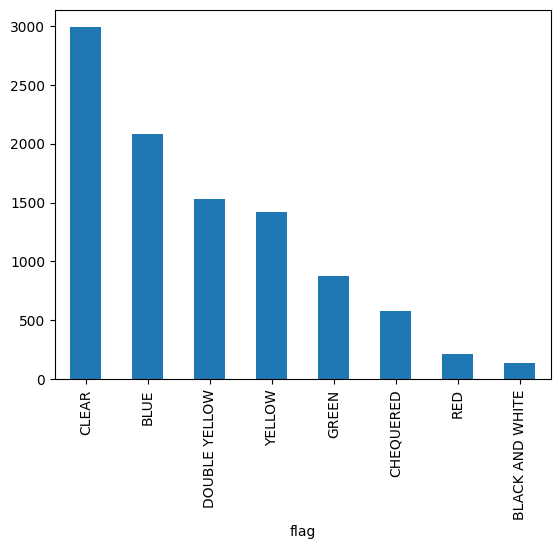

In [47]:
df['flag'].value_counts().plot(kind = 'bar')

In [48]:
flags = df[df['flag'].notna()]

In [49]:
 flags_by_lap = flags.groupby('lap_number')['flag'].value_counts().unstack().fillna(0)
 flags_by_lap

flag,BLACK AND WHITE,BLUE,CHEQUERED,CLEAR,DOUBLE YELLOW,GREEN,RED,YELLOW
lap_number,,,,,,,,
0.0,0.0,0.0,0.0,4.0,4.0,2.0,0.0,1.0
1.0,0.0,0.0,0.0,361.0,213.0,192.0,4.0,157.0
2.0,0.0,0.0,0.0,24.0,16.0,0.0,1.0,9.0
3.0,0.0,0.0,0.0,30.0,10.0,0.0,0.0,4.0
4.0,0.0,0.0,0.0,25.0,3.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
74.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0
75.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0
76.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0


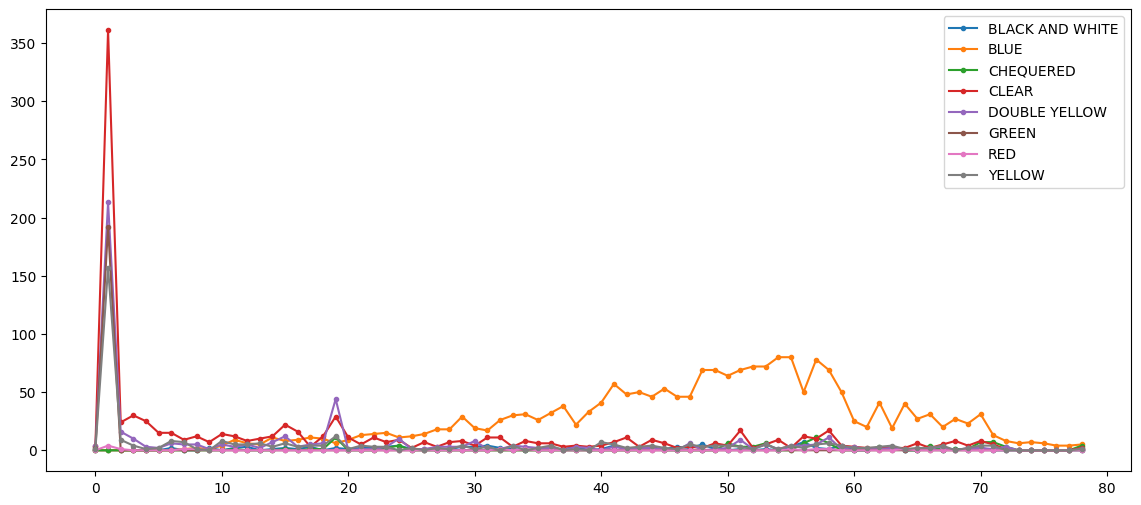

In [50]:
plt.figure(figsize=(14, 6))
for flag in flags_by_lap.columns:
    plt.plot(flags_by_lap.index, flags_by_lap[flag], label=flag, marker='o', markersize=3)

plt.legend()

#Sector

участок гоночной трассы

In [51]:
df['sector'].notna().sum()

np.int64(5552)

In [52]:
df['sector'].min(), df['sector'].max()

(1.0, 29.0)

In [53]:
df['sector'].value_counts()

,count
sector,
2.0,443
15.0,367
6.0,357
5.0,355
3.0,314
11.0,306
16.0,306
9.0,303
13.0,296


#qualifying_phase

предварительные заезды на время, которые определяют стартовую позицию каждого гонщика в основной гонке

In [54]:
df['qualifying_phase'].notna().sum()

np.int64(2857)

In [55]:
df['qualifying_phase'].value_counts()

,count
qualifying_phase,
1.0,1091
3.0,946
2.0,820


In [56]:
df[df['qualifying_phase'] == 1.0]

,meeting_key,session_key,date,driver_number,lap_number,category,flag,scope,sector,qualifying_phase,message,hour,minute,day_of_week,month
240,1141,7768,2023-03-04 15:00:00+00:00,NaN,NaN,Flag,GREEN,Track,NaN,1.0,GREEN LIGHT - PIT EXIT OPEN,15,0,5,3
241,1141,7768,2023-03-04 15:00:00.249000+00:00,NaN,NaN,SessionStatus,None,None,NaN,1.0,SESSION STARTED,15,0,5,3
242,1141,7768,2023-03-04 15:04:37.916000+00:00,NaN,NaN,SessionStatus,None,None,NaN,1.0,SESSION ABORTED,15,4,5,3
243,1141,7768,2023-03-04 15:04:38+00:00,NaN,NaN,Flag,RED,Track,NaN,1.0,RED FLAG,15,4,5,3
244,1141,7768,2023-03-04 15:08:36+00:00,NaN,NaN,Flag,CLEAR,Track,NaN,1.0,TRACK CLEAR,15,8,5,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20110,1287,11303,2026-06-13 14:20:16+00:00,NaN,NaN,Flag,YELLOW,Sector,6.0,1.0,YELLOW IN TRACK SECTOR 6,14,20,5,6
20111,1287,11303,2026-06-13 14:20:23+00:00,NaN,NaN,Flag,YELLOW,Sector,10.0,1.0,YELLOW IN TRACK SECTOR 10,14,20,5,6
20112,1287,11303,2026-06-13 14:20:24+00:00,NaN,NaN,Flag,CLEAR,Sector,6.0,1.0,CLEAR IN TRACK SECTOR 6,14,20,5,6
20114,1287,11303,2026-06-13 14:20:57+00:00,NaN,NaN,Flag,CLEAR,Sector,10.0,1.0,CLEAR IN TRACK SECTOR 10,14,20,5,6


In [57]:
df[df['qualifying_phase'].isna()]

,meeting_key,session_key,date,driver_number,lap_number,category,flag,scope,sector,qualifying_phase,message,hour,minute,day_of_week,month
0,1140,7763,2023-02-24 06:45:11+00:00,NaN,NaN,Other,None,None,NaN,NaN,RISK OF RAIN FOR THIS SESSION IS 0%,6,45,4,2
1,1140,7763,2023-02-24 06:57:05+00:00,NaN,NaN,Drs,None,None,NaN,NaN,DRS ENABLED,6,57,4,2
2,1140,7763,2023-02-24 07:00:00+00:00,NaN,NaN,Flag,GREEN,Track,NaN,NaN,GREEN LIGHT - PIT EXIT OPEN,7,0,4,2
3,1140,7763,2023-02-24 07:00:00.217000+00:00,NaN,NaN,SessionStatus,None,None,NaN,NaN,SESSION STARTED,7,0,4,2
4,1140,7763,2023-02-24 11:00:03+00:00,NaN,NaN,Flag,DOUBLE YELLOW,Sector,6.0,NaN,DOUBLE YELLOW IN TRACK SECTOR 6,11,0,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20708,1305,11470,2026-02-18 15:58:02+00:00,NaN,NaN,Other,None,None,NaN,NaN,STANDING START,15,58,2,2
20709,1305,11470,2026-02-18 16:00:44+00:00,NaN,NaN,Flag,DOUBLE YELLOW,Sector,2.0,NaN,DOUBLE YELLOW IN TRACK SECTOR 2,16,0,2,2
20710,1305,11470,2026-02-18 16:01:13+00:00,NaN,NaN,Flag,CLEAR,Sector,2.0,NaN,CLEAR IN TRACK SECTOR 2,16,1,2,2
20711,1305,11470,2026-02-18 16:01:25+00:00,NaN,NaN,Other,None,None,NaN,NaN,RED FLAG - RACE SUSPENDED,16,1,2,2


сообщения предварительных заездов и главных не отличаюся

#Multivariable analysis

###Гонщики и категории

<Axes: xlabel='driver_number'>

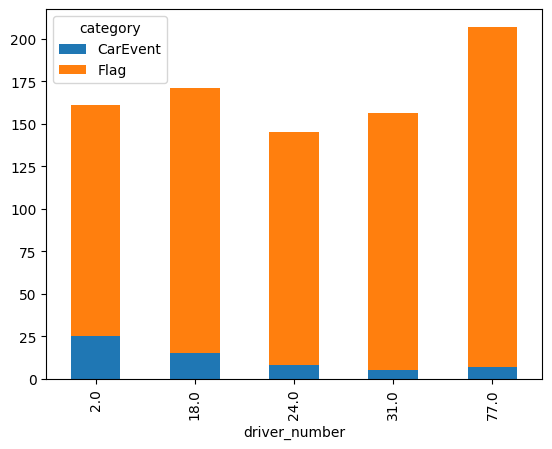

In [58]:
top_drivers = df['driver_number'].value_counts().head(5).index
driver_cat = df[df['driver_number'].isin(top_drivers)]
cat_driver = pd.crosstab(driver_cat['driver_number'], driver_cat['category'])

cat_driver.plot(kind='bar', stacked=True)

у Логан Сарджентпод номером 2 больше всего car event

In [59]:
df[df['category']=='CarEvent'].groupby(['driver_number'])['category'].count().sort_values()

,category
driver_number,
3.0,2
40.0,3
31.0,5
21.0,5
77.0,7
24.0,8
10.0,9
81.0,9
55.0,9


# Логистическая регрессия

оставляем данные по сессии и сообщению

In [60]:
df_message_with_line_end = df.copy()
df_message_with_line_end['message'] += '; '
grouped = df_message_with_line_end.groupby(['session_key'])['message'].sum().reset_index()
grouped

,session_key,message
0,7763,RISK OF RAIN FOR THIS SESSION IS 0%; DRS ENABL...
1,7764,AIR TEMPERATURE 1 HOUR BEFORE THE SESSION = 22...
2,7765,RISK OF RAIN FOR F1 FIRST PRACTICE SESSION IS ...
3,7766,RISK OF RAIN FOR F1 SECOND PRACTICE SESSION IS...
4,7767,RISK OF RAIN FOR F1 THIRD PRACTICE SESSION IS ...
...,...,...
395,11466,PINK HEAD PADDING MATERIAL MUST BE USED; CLEAR...
396,11467,SESSION STARTED; DOUBLE YELLOW IN TRACK SECTOR...
397,11468,PINK HEAD PADDING MATERIAL MUST BE USED; SESSI...
398,11469,PINK HEAD PADDING MATERIAL MUST BE USED; SESSI...


In [61]:
category_messsages_df = df[['message', 'category']].copy()
category_messsages_df['message'] = category_messsages_df['message'].replace(r'\d+', '', regex=True).replace(r'\s+', ' ', regex=True)

удалили цифры, нормализировали пробелы

In [62]:
noise = stopwords.words("english") + list(string.punctuation)

сделали список шумовых символов

делим на тестовую и обучающие выборки:

In [63]:
X_train, X_test, y_train, y_test = train_test_split(category_messsages_df['message'],category_messsages_df['category'],
    test_size=0.2,
    stratify=category_messsages_df['category']) #сохраняем пропорции классов

In [70]:
logreg_model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 3), lowercase=True, stop_words=noise)),
    ("clf", LogisticRegression(class_weight="balanced"))
])

logreg_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(ngram_range=(1, 3),
                                 stop_words=['a', 'about', 'above', 'after',
                                             'again', 'against', 'ain', 'all',
                                             'am', 'an', 'and', 'any', 'are',
                                             'aren', "aren't", 'as', 'at', 'be',
                                             'because', 'been', 'before',
                                             'being', 'below', 'between',
                                             'both', 'but', 'by', 'can',
                                             'couldn', "couldn't", ...])),
                ('clf', LogisticRegression(class_weight='balanced'))])

In [69]:
svm_model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 3), lowercase=True, stop_words=noise)),
    ("clf", LinearSVC(class_weight="balanced",))
])

svm_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(ngram_range=(1, 3),
                                 stop_words=['a', 'about', 'above', 'after',
                                             'again', 'against', 'ain', 'all',
                                             'am', 'an', 'and', 'any', 'are',
                                             'aren', "aren't", 'as', 'at', 'be',
                                             'because', 'been', 'before',
                                             'being', 'below', 'between',
                                             'both', 'but', 'by', 'can',
                                             'couldn', "couldn't", ...])),
                ('clf', LinearSVC(class_weight='balanced'))])

Logistic Regression
Accuracy: 0.9990345160511707
Macro F1: 0.998418692313904
               precision    recall  f1-score   support

     CarEvent       1.00      1.00      1.00        48
          Drs       1.00      1.00      1.00        86
         Flag       1.00      1.00      1.00      1965
        Other       1.00      1.00      1.00      1660
    SafetyCar       0.99      1.00      0.99        66
SessionStatus       1.00      1.00      1.00       318

     accuracy                           1.00      4143
    macro avg       1.00      1.00      1.00      4143
 weighted avg       1.00      1.00      1.00      4143

Linear SVM
Accuracy: 0.9990345160511707
Macro F1: 0.998418692313904
               precision    recall  f1-score   support

     CarEvent       1.00      1.00      1.00        48
          Drs       1.00      1.00      1.00        86
         Flag       1.00      1.00      1.00      1965
        Other       1.00      1.00      1.00      1660
    SafetyCar       0.99  

Логистическая регрессия

In [73]:
logreg_model.fit(X_train, y_train)
y_pred = logreg_model.predict(X_test)

print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     CarEvent       1.00      1.00      1.00        48
          Drs       1.00      1.00      1.00        86
         Flag       1.00      1.00      1.00      1965
        Other       1.00      1.00      1.00      1660
    SafetyCar       0.99      1.00      0.99        66
SessionStatus       1.00      1.00      1.00       318

     accuracy                           1.00      4143
    macro avg       1.00      1.00      1.00      4143
 weighted avg       1.00      1.00      1.00      4143



In [74]:
accuracy_score(y_test, y_pred)

0.9990345160511707

In [76]:
f1_score(y_test, y_pred, average="macro")

0.998418692313904

вау!

# Метод опорных векторов

In [78]:
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     CarEvent       1.00      1.00      1.00        48
          Drs       1.00      1.00      1.00        86
         Flag       1.00      1.00      1.00      1965
        Other       1.00      1.00      1.00      1660
    SafetyCar       0.99      1.00      0.99        66
SessionStatus       1.00      1.00      1.00       318

     accuracy                           1.00      4143
    macro avg       1.00      1.00      1.00      4143
 weighted avg       1.00      1.00      1.00      4143



In [79]:
accuracy_score(y_test, y_pred)

0.9990345160511707

In [80]:
f1_score(y_test, y_pred, average="macro")

0.998418692313904

При получении расшифровки сообщений от судей мы сможем с помощью нашей модели с максимальной точностью классифицировать категории сообщений и во время гонки. Будем радовать нашего фаната уведомлениями-сообщениями о самых важных моментах заезда (появлении флага у гонщика, машины безопасности на трассе и тд)

# Нейроночка

все по сему нлп!!!

In [7]:
df = df[['message', 'category']].dropna()

энкодер создаем для преобразования категорий в числа и обучаемся на данных

In [8]:
le = LabelEncoder()
df['encoded_label'] = le.fit_transform(df['category'])

векторизируем

In [10]:
texts = df['message'].astype(str).tolist()
labels = df['encoded_label'].tolist()

In [11]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    stratify=labels,
)

Создаем словарь:

In [13]:
def tokenize(text):
    return text.lower().split()

# добавим в словарь специальные токены для паддинга и для out-of-vocabulary слов
PAD_TOKEN = "<PAD>" #токены для выравнивания длин предложений (индекс 0)
UNK_TOKEN = "<UNK>" #токены <UNK> — для неизвестных слов (индекс 1)

#Проходим по всем обучающим текстам, токенизируем каждый и считаем частоту каждого слова

counter = Counter()

for text in train_texts:
    counter.update(tokenize(text))

vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}

Проходим по всем словам в счетчике, если слово встречается больше 2 раз то добавляем в словарь

Индексом становится текущая длина словаря

In [14]:
for word, freq in counter.items():
    if freq >= 2:
        vocab[word] = len(vocab)

len(vocab)

994

Преобразовываем текста в индексы

In [18]:
MAX_LEN = 64 #макс длина последовательноссти

def text_to_ids(text):
    tokens = tokenize(text)
    ids = [vocab.get(token, vocab[UNK_TOKEN]) for token in tokens]

    return ids[:MAX_LEN]

In [51]:
class F1Dataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text_ids = text_to_ids(self.texts[idx])

        return (
            torch.tensor(text_ids, dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )


    def collate_fn(batch):

        texts, labels = zip(*batch)

        lengths = torch.tensor(
            [len(x) for x in texts],
            dtype=torch.long
        )

        texts = pad_sequence(
            texts,
            batch_first=True,
            padding_value=vocab[PAD_TOKEN]
        )

        labels = torch.tensor(labels)

        return texts, labels, lengths

    def collate_fn(batch):
        texts, labels = zip(*batch)
        lengths = torch.tensor([len(x) for x in texts],dtype=torch.long)
        texts = pad_sequence(texts, batch_first=True,padding_value=vocab[PAD_TOKEN])
        labels = torch.tensor(labels)

        return texts, labels, lengths

In [59]:
BATCH_SIZE = 64

#загрузжик для обучения
train_loader = DataLoader(
    F1Dataset(train_texts, train_labels),
    batch_size=BATCH_SIZE,
    shuffle=True, #переммешивает данные
    collate_fn=collate_fn
    )

#загрузчик для теста
test_loader = DataLoader(
    F1Dataset(test_texts, test_labels),
    batch_size=BATCH_SIZE,
    shuffle=False, #не перемешивает
    collate_fn=collate_fn
)

Мы собираемся использовать нейросеть для обучения классификатора. Поэтому посмотрим, есть ли у нас доступный девайс (cuda, если доступна видеокарта).

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cpu')

In [31]:
class BiLSTMClassifier(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()

        # слой обучаемых векторных представлений nn.Embedding
        # с размером словаря vocab_size,
        # размерностью эмбеддингов embed_dim
        # и индексом паддинга padding_idx=0
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # двунаправленный слой nn.LSTM,
        # принимающий на вход эмбеддинги размерности embed_dim
        # и возвращающий скрытые состояния размерности hidden_dim,
        # с использованием batch_first=True
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        # слой nn.Dropout для регуляризации
        # с вероятностью отключения нейронов 0.3
        self.dropout = nn.Dropout(0.3)

        # линейный слой nn.Linear,
        # преобразующий объединенные выходы двунаправленной LSTM
        # размерности hidden_dim * 2
        # в num_classes классов
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, text, lengths):

        # пропустим полученные на вход тексты через слой self.embedding
        embedded = self.embedding(text)

        # преобразуем последовательности эмбеддингов в специальный формат,
        # подходящий для обработки слоем LSTM
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)

        # пропустим упакованные последовательности через слой self.lstm
        # и получим скрытые состояния последнего шага
        _, (hidden, _) = self.lstm(packed)

        # объединим последние скрытые состояния прямого и обратного проходов
        # двунаправленной LSTM
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        # пропустим полученные скрытые представления через слой self.dropout
        hidden = self.dropout(hidden)

        # пропустим скрытые представления через линейный слой self.fc
        output = self.fc(hidden)

        return output

In [32]:
num_classes = len(le.classes_)

model = BiLSTMClassifier(vocab_size=len(vocab),embed_dim=128,hidden_dim=128,num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [61]:
EPOCHS = 10

for epoch in range(1, EPOCHS + 1):

    epoch_start_time = time.time()

    #переводим модель в режим обучения
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    #проходим по всем батчам обучающей выборки
    for texts, labels, lengths in train_loader:

        texts = texts.to(device)
        labels = labels.to(device)

        #обнуляем накопленные градиенты
        optimizer.zero_grad()

        #получаем предсказания модели
        outputs = model(texts, lengths)

        #вычисляем значение функции потерь
        loss = criterion(outputs, labels)

        #вычисляем градиенты
        loss.backward()

        #обновляем параметры модели
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    train_acc = correct / total

    print('-' * 59)
    print('| end of epoch {:3d} | time: {:5.2f}s | '
          'train loss {:8.3f} | train accuracy {:8.3f}'.format(
              epoch,
              time.time() - epoch_start_time,
              total_loss,
              train_acc))
    print('-' * 59)

-----------------------------------------------------------
| end of epoch   1 | time: 15.69s | train loss    0.004 | train accuracy    1.000
-----------------------------------------------------------
-----------------------------------------------------------
| end of epoch   2 | time: 15.19s | train loss    0.003 | train accuracy    1.000
-----------------------------------------------------------
-----------------------------------------------------------
| end of epoch   3 | time: 14.93s | train loss    0.003 | train accuracy    1.000
-----------------------------------------------------------
-----------------------------------------------------------
| end of epoch   4 | time: 14.72s | train loss    0.003 | train accuracy    1.000
-----------------------------------------------------------
-----------------------------------------------------------
| end of epoch   5 | time: 14.86s | train loss    0.002 | train accuracy    1.000
--------------------------------------------------

In [62]:
#переводим модель в режим оценки
model.eval()

all_preds = []
all_labels = []

#отключаем вычисление градиентов
with torch.no_grad():

    #проходим по всем батчам тестовой выборки
    for texts, labels, lengths in test_loader:

        texts = texts.to(device)

        #получаем предсказания модели
        outputs = model(texts, lengths)

        #выбираем класс с максимальной вероятностью
        preds = outputs.argmax(dim=1)

        #сохраняем предсказанные и истинные метки
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print('-' * 59)
print('| classification report')
print('-' * 59)

print(classification_report(all_labels,all_preds,target_names=le.classes_))

print('-' * 59)

-----------------------------------------------------------
| classification report
-----------------------------------------------------------
               precision    recall  f1-score   support

     CarEvent       1.00      1.00      1.00        48
          Drs       1.00      1.00      1.00        86
         Flag       1.00      1.00      1.00      1965
        Other       1.00      1.00      1.00      1660
    SafetyCar       1.00      1.00      1.00        66
SessionStatus       1.00      1.00      1.00       318

     accuracy                           1.00      4143
    macro avg       1.00      1.00      1.00      4143
 weighted avg       1.00      1.00      1.00      4143

-----------------------------------------------------------


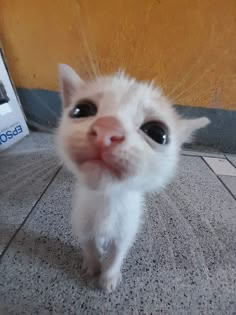